# Final Analytics Project: Predicting Banana Quality

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, mean_squared_error, r2_score, RocCurveDisplay, roc_auc_score


c:\Users\Prisha\Documents\DS 3021\Final Project\Final-Project-banana\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading the Dataset
The dataset "Banana Quality Dataset" comes from Kaggle: https://www.kaggle.com/datasets/mrmars1010/banana-quality-dataset/data

In [3]:
df = pd.read_csv("banana_quality_dataset.csv")
df.set_index('sample_id', inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 1 to 1000
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   variety             1000 non-null   str    
 1   region              1000 non-null   str    
 2   quality_score       1000 non-null   float64
 3   quality_category    1000 non-null   str    
 4   ripeness_index      1000 non-null   float64
 5   ripeness_category   1000 non-null   str    
 6   sugar_content_brix  1000 non-null   float64
 7   firmness_kgf        1000 non-null   float64
 8   length_cm           1000 non-null   float64
 9   weight_g            1000 non-null   float64
 10  harvest_date        1000 non-null   str    
 11  tree_age_years      1000 non-null   float64
 12  altitude_m          1000 non-null   float64
 13  rainfall_mm         1000 non-null   float64
 14  soil_nitrogen_ppm   1000 non-null   float64
dtypes: float64(10), str(5)
memory usage: 117.3 KB


In [ ]:
# Initial look at summary statistics 
df.describe(include='all')

,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,harvest_date,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
count,1000,1000,1000.000000,1000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000
unique,8,8,NaN,4,NaN,4,NaN,NaN,NaN,NaN,61,NaN,NaN,NaN,NaN
top,Plantain,Ecuador,NaN,Processing,NaN,Ripe,NaN,NaN,NaN,NaN,2023-10-30,NaN,NaN,NaN,NaN
freq,146,137,NaN,506,NaN,349,NaN,NaN,NaN,NaN,28,NaN,NaN,NaN,NaN
mean,NaN,NaN,2.465160,NaN,4.042170,NaN,18.516830,2.706840,19.882100,164.738930,NaN,10.879600,723.556700,1972.992800,104.391300
std,NaN,NaN,0.540909,NaN,1.753211,NaN,2.034812,1.289252,5.736318,49.163073,NaN,5.215554,427.372855,564.467912,53.607794
min,NaN,NaN,0.920000,NaN,1.020000,NaN,15.000000,0.500000,10.000000,81.050000,NaN,2.000000,0.400000,1000.500000,10.000000
25%,NaN,NaN,2.090000,NaN,2.447500,NaN,16.827500,1.590000,14.902500,122.397500,NaN,6.300000,353.950000,1498.750000,60.150000
50%,NaN,NaN,2.440000,NaN,4.110000,NaN,18.500000,2.680000,19.890000,163.365000,NaN,10.700000,726.000000,1957.400000,104.100000
75%,NaN,NaN,2.850000,NaN,5.562500,NaN,20.312500,3.820000,24.800000,205.775000,NaN,15.600000,1071.725000,2431.800000,149.850000


In [5]:
# Checking for missing values - there are none!
print(df.isna().sum())

variety               0
region                0
quality_score         0
quality_category      0
ripeness_index        0
ripeness_category     0
sugar_content_brix    0
firmness_kgf          0
length_cm             0
weight_g              0
harvest_date          0
tree_age_years        0
altitude_m            0
rainfall_mm           0
soil_nitrogen_ppm     0
dtype: int64


## Research Question and EDA

**Refining Research Question**
This dataset describes properties of 1,000 banana samples. The most informative aspect of this dataset is the quality of the banana. We are given two measures of quality: **quality_score** and **quality_category**. First, let's see if these features are directly correlated

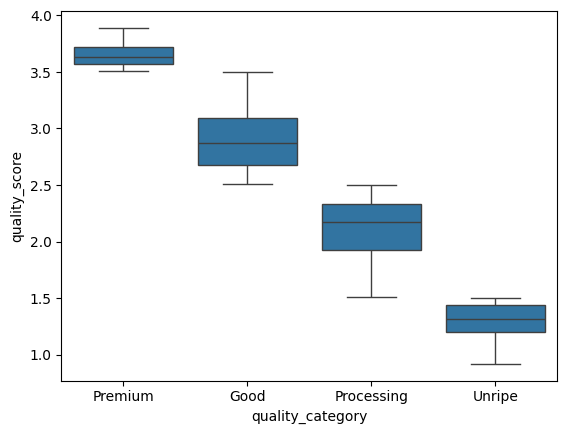

In [6]:
sns.boxplot(x="quality_category", y="quality_score", data=df, order=["Premium", "Good", "Processing", "Unripe"])

plt.show()

In [ ]:
# Checking to see where the boundaries fall for the quality score and category (box plot does not show the exact cutoff)
print("Boundary Cutoffs— Category for score of 1.5:", df[df['quality_score'] == 1.5]['quality_category'].value_counts())
print("Boundary Cutoffs— Category for score of 2.5:", df[df['quality_score'] == 2.5]['quality_category'].value_counts())
print("Boundary Cutoffs— Category for score of 3.5:", df[df['quality_score'] == 3.5]['quality_category'].value_counts())


Boundary Cutoffs— Category for score of 1.5: quality_category
Unripe    2
Name: count, dtype: int64
Boundary Cutoffs— Category for score of 2.5: quality_category
Processing    9
Name: count, dtype: int64
Boundary Cutoffs— Category for score of 3.5: quality_category
Good    4
Name: count, dtype: int64


As we can see from this analysis, quality score and category are directly related as such:
- Scores between **[Minimum, 1.5]** are in the **Unripe** category
- Scores between **(1.5, 2.5]** are in the **Processing** category
- Scores between **(2.5, 3.5]** are in the **Good** category
- Scores between **(3.5, Maximum]** are in the **Unripe** category

Therefore, **we can make either a classification model OR a regression model for this dataset**! We decided to try some different models out, so we will do both a **decision tree** that predicts the class of quality_score and a **linear regression model** that predicts the value of quality_category. Because these two target variables are perfectly aligned with eachother via score thresholds, we can directly compare these two types of models and determine which performs better. 

### X Variables - EDA and Pre Processing

In [8]:
X = df.drop(columns=['quality_score', 'quality_category'])

### Numerical

In [9]:
NUM = X.select_dtypes(include=np.number).columns.tolist()
X[NUM].describe()

,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.042170,18.516830,2.706840,19.882100,164.738930,10.879600,723.556700,1972.992800,104.391300
std,1.753211,2.034812,1.289252,5.736318,49.163073,5.215554,427.372855,564.467912,53.607794
min,1.020000,15.000000,0.500000,10.000000,81.050000,2.000000,0.400000,1000.500000,10.000000
25%,2.447500,16.827500,1.590000,14.902500,122.397500,6.300000,353.950000,1498.750000,60.150000
50%,4.110000,18.500000,2.680000,19.890000,163.365000,10.700000,726.000000,1957.400000,104.100000
75%,5.562500,20.312500,3.820000,24.800000,205.775000,15.600000,1071.725000,2431.800000,149.850000
max,7.000000,21.980000,5.000000,29.950000,249.890000,20.000000,1498.400000,2992.000000,199.900000


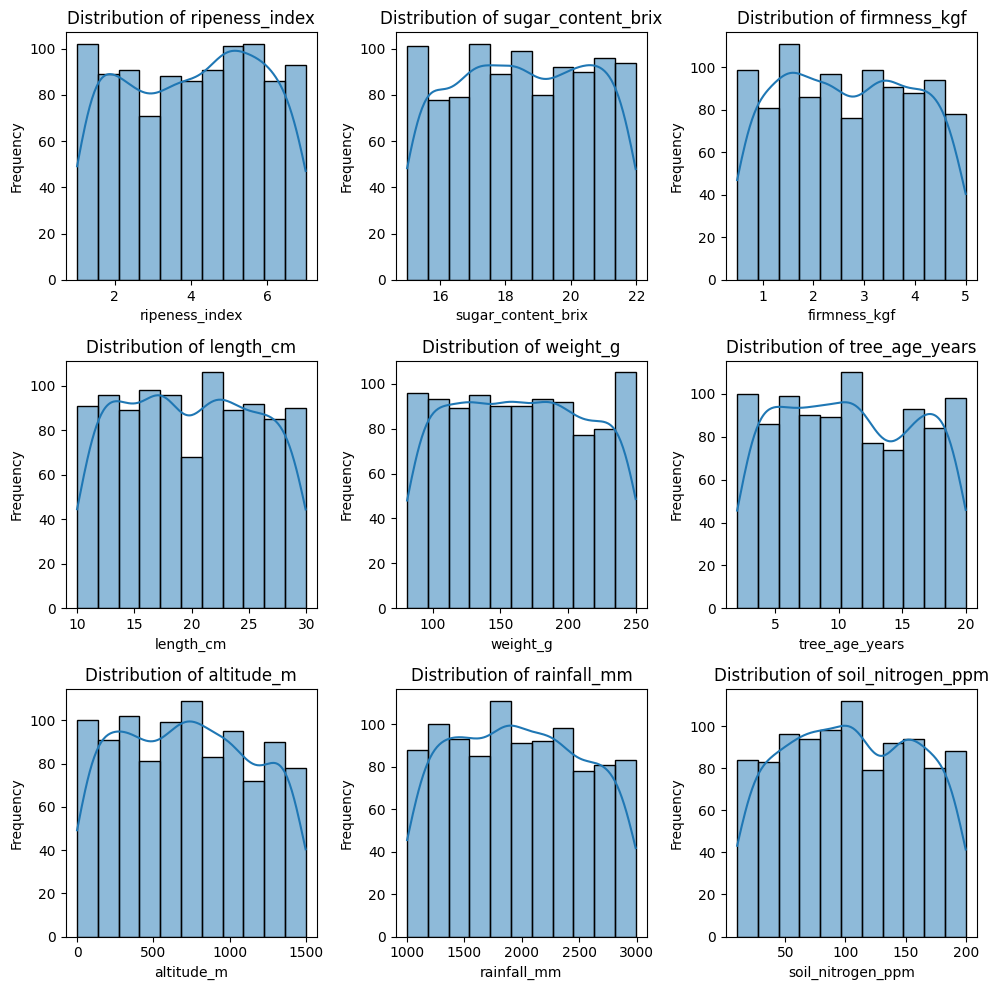

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i,col in enumerate(NUM):
    sns.histplot(X[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

As seen by the distributions, these numerical variables are already normalized.

##### EDA of Numerical Features

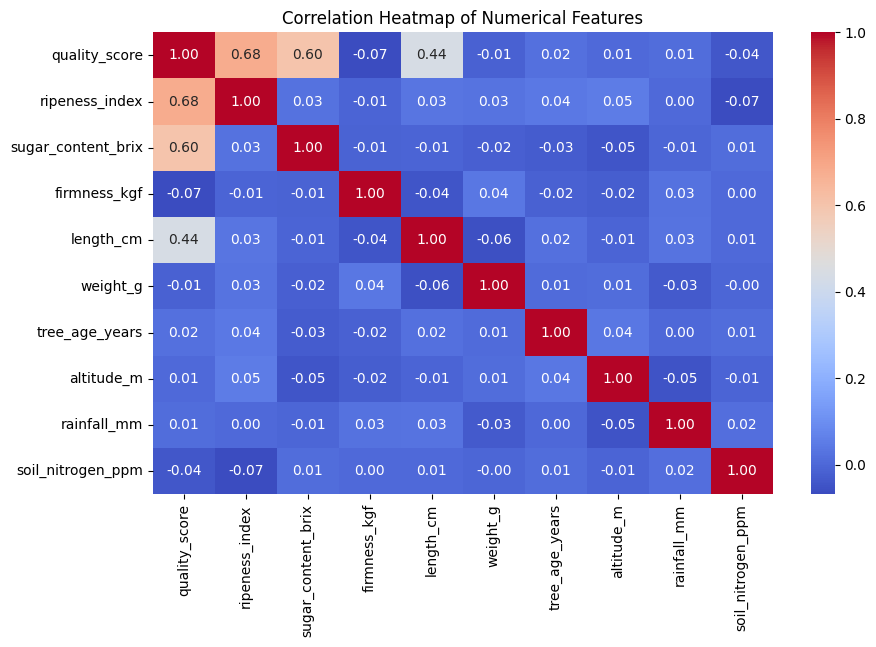

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The three main features that seem to correlate with the quality score are the 'ripeness_index', 'sugar_content_brix', and 'length_cm'. The following plots take a closer look at the relationships between the features.

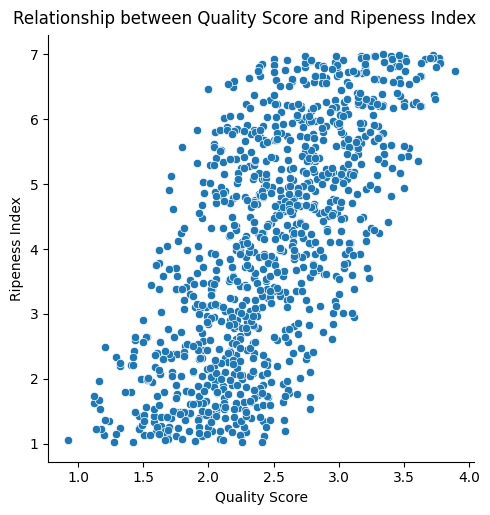

In [51]:
sns.relplot(x='quality_score', y='ripeness_index', data=df)
plt.xlabel('Quality Score')
plt.ylabel('Ripeness Index')
plt.suptitle('Relationship between Quality Score and Ripeness Index', y=1.02)
plt.show()

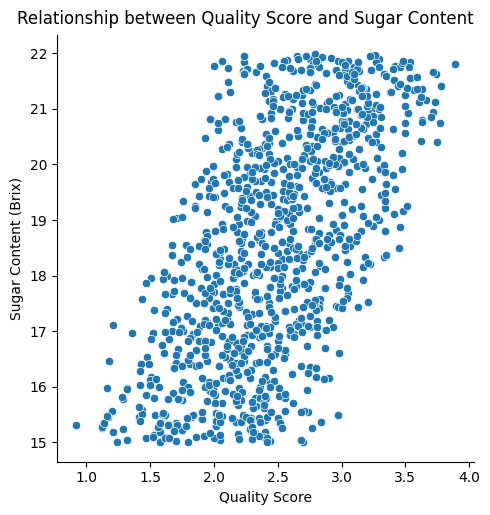

In [50]:
sns.relplot(x='quality_score', y='sugar_content_brix', data=df)
plt.xlabel('Quality Score')
plt.ylabel('Sugar Content (Brix)')
plt.suptitle('Relationship between Quality Score and Sugar Content', y=1.02)
plt.show()

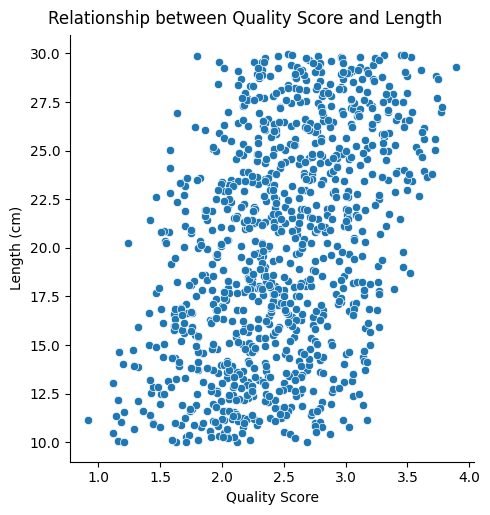

In [52]:
sns.relplot(x='quality_score', y='length_cm', data=df)
plt.xlabel('Quality Score')
plt.ylabel('Length (cm)')
plt.suptitle('Relationship between Quality Score and Length', y=1.02)
plt.show()

All three features show a positive correlation with quality score at first glance. As one increases, so does the other.

##### Checking the Target Feature

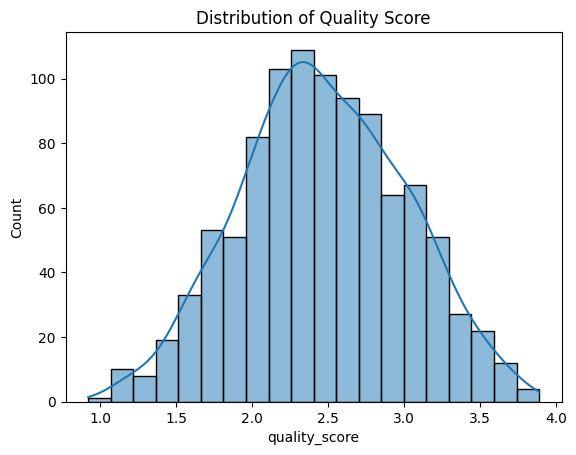

In [11]:
sns.histplot(df['quality_score'], kde=True)
plt.title("Distribution of Quality Score")
plt.show()

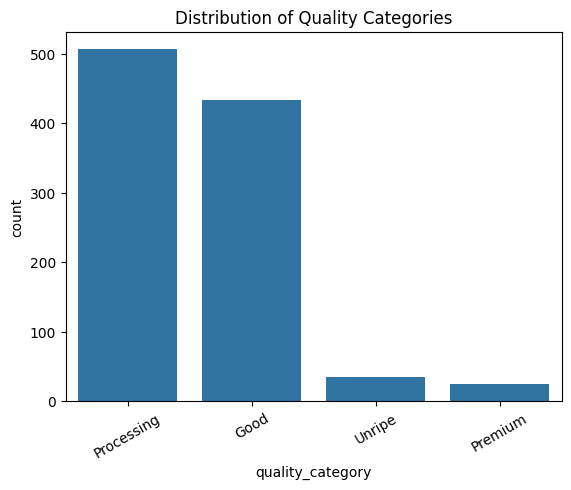

In [36]:
sns.countplot(x=df['quality_category'], order=df['quality_category'].value_counts().index)
plt.title("Distribution of Quality Categories")
plt.xticks(rotation=30)
plt.show()

Quality score has a normal distribution that will likely work well for the regression; however quality category raises an area for concern with the class distribution. The classification model may not perform as well due to the limited data points in the 'Unripe' and 'Premium' classes.

### Categorical

In [ ]:
# Defining categorical variables
CAT = X.select_dtypes(include='str').columns.tolist()
print(CAT)

['variety', 'region', 'ripeness_category', 'harvest_date']


**Observations of Categorical Features**
- The feature **"variety"** has 8 categories, all of which are evenly distributed. Therefore, we will **keep all categories of "variety"**.
- The feature **'ripeness category'** is redundant with ripeness index, so we will **remove** it. 
- The feature **harvest date** is not relevant, so we will **remove** it.


In [13]:
X = X.drop(columns=['ripeness_category', 'harvest_date'])

- The feature **"region"** has 8 categories, all of which are evenly distibuted. However, we will **collapse these features** into larger regions to reduce the amount of categories.

In [ ]:
# Organize regions into larger categories (Souther America, Central America, Asia)
X['region'] = X['region'].replace({
    'Ecuador': 'South America',
    'Colombia': 'South America',
    'Brazil': 'South America',
    'Costa Rica': 'Central America',
    'Guatemala': 'Central America',
    'Honduras': 'Central America',
    'Philippines': 'Asia',
    'India': 'Asia'
})

X['region'].value_counts()
    

region
South America      377
Central America    363
Asia               260
Name: count, dtype: int64

In [ ]:
# Redefining CAT after editing the categorical columns
CAT = X.select_dtypes(include='str').columns.tolist()
X.head()

,variety,region,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
sample_id,,,,,,,,,,,
1,Manzano,South America,2.11,16.83,3.53,21.44,146.92,13.7,58.2,2440.5,183.6
2,Plantain,Central America,4.25,16.73,4.09,26.11,160.48,5.1,280.2,2374.6,109.8
3,Burro,South America,6.24,21.34,1.63,25.20,225.27,17.7,1246.9,1191.5,147.7
4,Manzano,South America,5.39,16.75,3.31,13.08,137.80,13.0,1150.2,2845.1,92.8
5,Red Dacca,South America,5.84,16.90,3.07,12.98,227.84,4.8,526.0,2136.9,129.7


##### EDA of Categorical Features

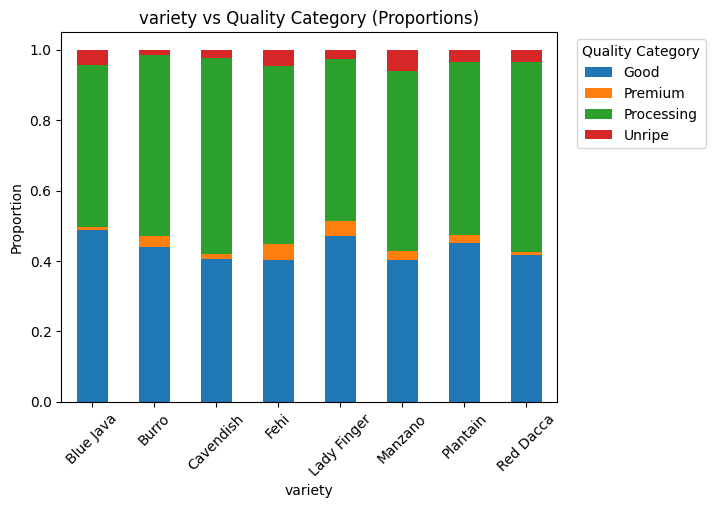

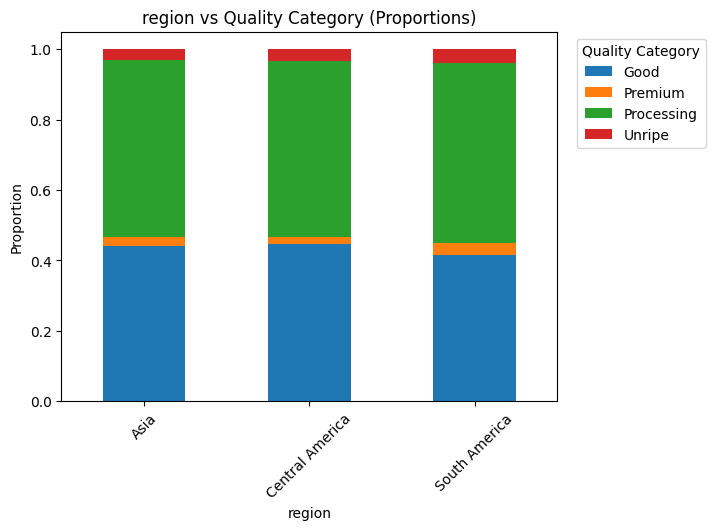

In [73]:
for col in CAT:
    ct = pd.crosstab(X[col], df['quality_category'], normalize='index')
    ct.plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Quality Category (Proportions)")
    plt.legend(title='Quality Category', bbox_to_anchor=(1.025, 1), loc='upper left')
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.show()

There seems to be a pretty even distribution of the various quality classes in each region as well as in the different banana types. This suggests the variety of banana or region alone may not have the strongest impact of the quality class, but it may still have an impact on the actual quality score.

## Model #1: Linear Regression
We will start our Methods section by building a linear regression model, which predicts quality score.

In [ ]:
# Defining our predictor and target variables for regression
X1 = X
y1 = df['quality_score']

In [ ]:
# Split data intro training, tuning, and test sets (70% training, 15% tuning, 15% test)
X1_train, X1_temp, y1_train, y1_temp = train_test_split(X1, y1, test_size=0.3, random_state=40)

# Split into tuning and validation sets
X1_tune, X1_test, y1_tune, y1_test = train_test_split(X1_temp, y1_temp, test_size=0.5, random_state=40)


In [ ]:
# Creating the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)  #categorical features will be one hot encoded
    ],
    remainder="passthrough" # the remaining numerical columns will be passed through without transformation, as they are already normalized
)

In [ ]:
# Creating a pipeline for Model 1: Linear Regression
model_1_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression(fit_intercept=True, copy_X=True)) #although these are default parameters of the linear regression model, we will still clarify them here for transparency
])

In [ ]:
# Fitting model to our training data
model_1_pipeline.fit(X1_train, y1_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

### Evaluation

In [ ]:
# Finding RMSE and R2 metrics for the training set
y_train_pred = model_1_pipeline.predict(X1_train)

mse_train = mean_squared_error(y1_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
normalized_rmse = rmse_train / (y1_train.max() - y1_train.min())


r2_train = r2_score(y1_train, y_train_pred)

print("RMSE for training set:", rmse_train)
print("Normalized RMSE for training set:", normalized_rmse)
print("R2 for training set:", r2_train)

RMSE for training set: 0.07001898626816232
Normalized RMSE for training set: 0.025277612371177732
R2 for training set: 0.9841049468806219


**Observations:** The evaluations of training set analyze how well the model can memorize training data. The metrics are as follows:
- **RMSE: 0.0697**
    - The average of squared errors is very low, indicating that the model makes very accurate predictions of the training data. 
- **Normalized RMSE: 0.0252**
    - This simply scales RMSE to the same distbution of the data. Since the quality feature ranges from [0.92, 3.98], on average the errors that the model makes will only be 0.025 points off from the correct score. This is very good considering that the category boundaries for quality (unripe, good, etc.) are within 1 score point. If the average error is only 0.025, it is highly unlikely that the model will incorrectly predict quality category.
- **R2: 0.9841**
    - 98.41% of the variance in the target variable in the training set is explained by the model.




In [ ]:
# Finding RMSE and R2 metrics for the testing set
y_test_pred = model_1_pipeline.predict(X1_test)

mse_test = mean_squared_error(y1_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
normalized_rmse = rmse_test / (y1_test.max() - y1_test.min())

r2_test = r2_score(y1_test, y_test_pred)

print("RMSE for test set:", rmse_test)
print("Normalized RMSE for test set:", normalized_rmse)
print("R2 for test set:", r2_test)

RMSE for test set: 0.06574920723243687
Normalized RMSE for test set: 0.02797838605635612
R2 for test set: 0.9821320982160724


**Observations:** The evaluations of the testing set analyze how well the model makes predictions on unknown data. The metrics of the testing set are nearly equivalent to those of the training set, indicating that the model performs very well with both known and unknown data. They are as follows:

- **RMSE: 0.0619**
    - The average of squared errors is very low, indicating that the model makes very accurate predictions on unknown data.
- **Normalized RMSE: 0.0217**
    - On average the errors that the model makes will only be 0.022 points off from the correct score. 
- **R2: 0.9841**
    - 98.41% of the variance in the target variable in the testing set is explained by the model.


Text(0.5, 1.0, 'Residual Plot')

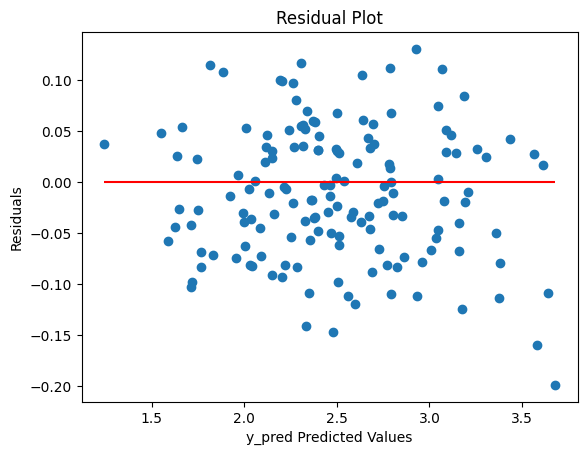

In [ ]:
# Comparing predicted values to actual values for the test set
y_true = y1_test
y_pred = model_1_pipeline.predict(X1_test)

# Compute residuals 
residuals = y_true - y_pred

# Plot residuals
plt.scatter(y_pred, residuals)
plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color='red') #i made horizontal line through y = 0 to see the scatter pattern
plt.xlabel("y_pred Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

Text(0.5, 1.0, 'KDE of Residuals')

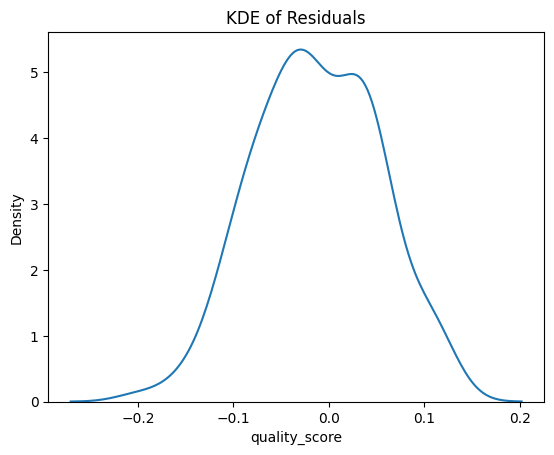

In [ ]:
# Another way to visualize the residuals is through a KDE plot
sns.kdeplot(data=residuals)
plt.title("KDE of Residuals")

**Observations:** 

- A plot of the residuals displays a **random scatter of residuals**, implying that there are no underlying patterns, trends, or bias. This means a linear model is likely a good fit.

- The KDE plot of residuals also shows that the **residuals follow a normal distribution and are centered at 0** *(mean residual value is zero)*. This shows that there is no skew in the residuals, so a linear model is a good fit.

In [ ]:
# Evaluating the model through cross validation
from sklearn.model_selection import cross_val_score, KFold
folds = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_1_pipeline, X, y1, cv=folds, verbose=1, scoring='neg_root_mean_squared_error')
print("Cross-validation RMSE scores:", -cv_scores)

Cross-validation RMSE scores: [0.07170421 0.06580341 0.0663941  0.07085188 0.07196316]


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


**Observations:**
Across multiple data splits, the RMSE remains low. Because k-folds ensures that all data points are used for both training and testing, a low RMSE across all folds indicates that the model is good at generalizing to new data, no matter what the split is.


### Feature Evaluation

In [ ]:
#Find coefficients of the linear regression model 

#Get the linear regression model from the pipeline
linear_model = model_1_pipeline.named_steps['model']
#Get the feature names from the preprocessor
feature_names = model_1_pipeline.named_steps['preprocessor'].get_feature_names_out()
#Get the coefficients from the linear model
coefficients = linear_model.coef_

#Create a dataframe to display the feature names and their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})  

#Order coefficients from highest to lowest absolute value to see which features have the most impact 
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print(coef_df)

                          Feature   Coefficient
11      remainder__ripeness_index  2.008832e-01
12  remainder__sugar_content_brix  1.563292e-01
14           remainder__length_cm  3.993046e-02
13        remainder__firmness_kgf -1.582906e-02
4        cat__variety_Lady Finger -1.332974e-02
3               cat__variety_Fehi  1.050567e-02
10      cat__region_South America -3.884330e-03
0          cat__variety_Blue Java  3.545825e-03
6           cat__variety_Plantain -2.173771e-03
9     cat__region_Central America  1.950265e-03
8                cat__region_Asia  1.934064e-03
5            cat__variety_Manzano  1.361241e-03
1              cat__variety_Burro -1.194812e-03
2          cat__variety_Cavendish  1.116761e-03
16      remainder__tree_age_years  2.900423e-04
7          cat__variety_Red Dacca  1.688259e-04
19   remainder__soil_nitrogen_ppm -7.977548e-05
15            remainder__weight_g  3.958671e-05
17          remainder__altitude_m  1.280300e-06
18         remainder__rainfall_mm -2.030

**Observations:**
It appears that ripeness index, sugar content, and length of the banana have the most impact on its quality status.
Altitude and rainfall have the least effect.

# Model #2: Decision Tree Classifier
The second part of our Methods section will be building a decision tree, which predicts quality category.

In [26]:
# Splitting target variable and features
X_2 = X
y_2 = df['quality_category']

In [27]:
# Splitting the data into training, tuning, and test sets with stratification to maintain class distribution

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_2, y_2, test_size=0.3, random_state=40, stratify=y_2
)

X2_tune, X2_test, y2_tune, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.5, random_state=40, stratify=y2_temp
)

In [ ]:
# Encode the target variable for the decision tree model

le_target = LabelEncoder() # needed to convert the categorical target variable into numerical format for the decision tree model
le_target.fit(y_2)

# Create a pipeline that combines the preprocessor and the decision tree model
model_2_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=40, class_weight='balanced')) # class_weight = 'balanced' is needed to address class imbalance particularly for the "Premium" category
])


model_2_pipeline.fit(X2_train, y2_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

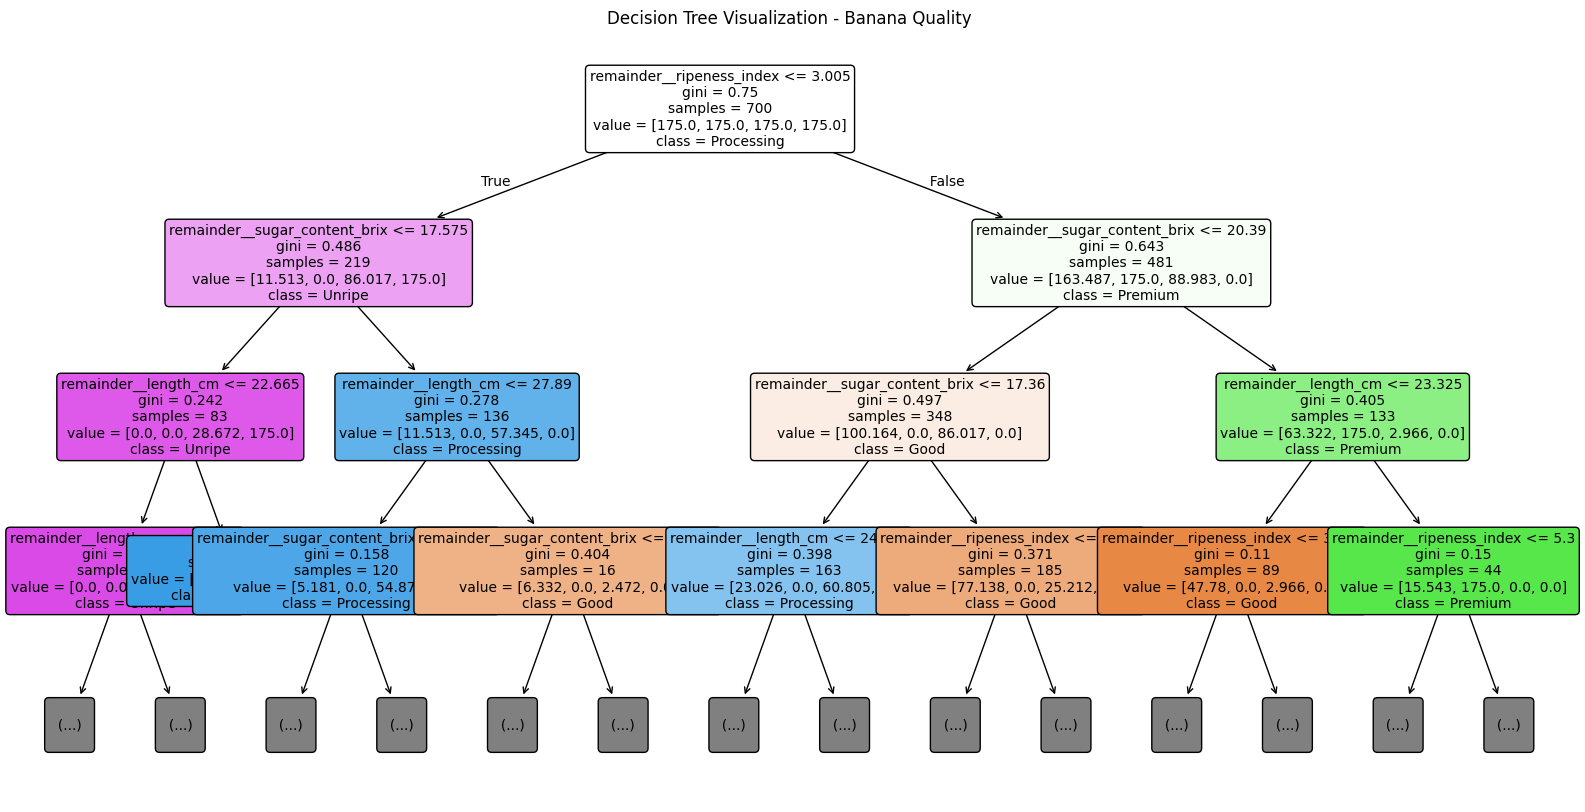

In [ ]:
# Visualize the decision tree

tree_model = model_2_pipeline.named_steps['model']


feature_names = model_2_pipeline.named_steps['preprocessor'].get_feature_names_out()


plt.figure(figsize=(20, 10)) 
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=le_target.classes_,
    filled=True,         # Colors nodes by class
    rounded=True,       # Makes boxes look nicer
    fontsize=10,
    max_depth=3          # Limits depth so the image isn't a mess
)

plt.title("Decision Tree Visualization - Banana Quality")
plt.show()

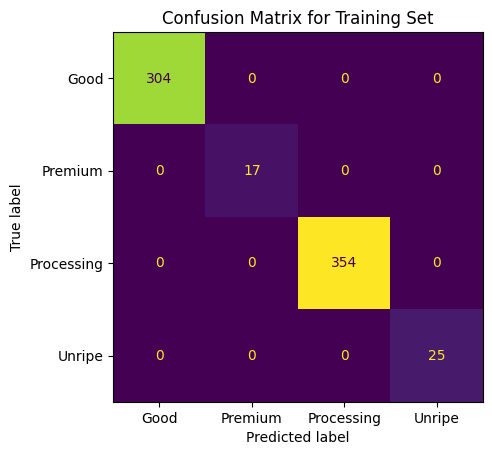

In [86]:
# Evaluate model on training set using confusion matrix

y2_pred_train = model_2_pipeline.predict(X2_train)

disp = ConfusionMatrixDisplay.from_predictions(
    y2_train, y2_pred_train, 
    display_labels=le_target.classes_, 
    colorbar=False
    )
plt.title("Confusion Matrix for Training Set")
plt.show()

The decision tree fits the training set perfectly suggesting it may have overfit to the training set, so it is important to check the model on another test set that it has not seen before.

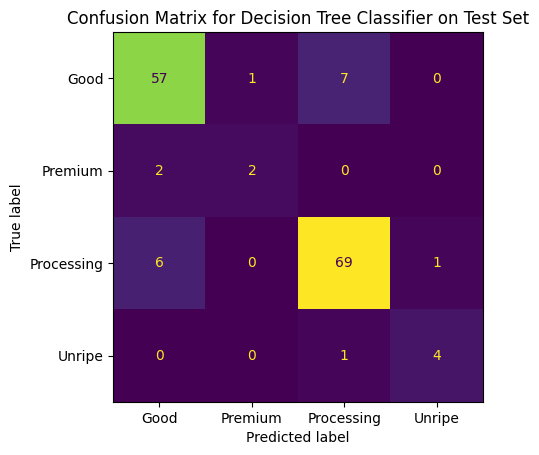

In [87]:
# Evaluate model on test set using confusion matrix

y2_pred_test = model_2_pipeline.predict(X2_test)
y2_prob_test = model_2_pipeline.predict_proba(X2_test)


disp = ConfusionMatrixDisplay.from_predictions(
    y2_test, y2_pred_test,
    display_labels=le_target.classes_,
    colorbar=False
)
plt.title('Confusion Matrix for Decision Tree Classifier on Test Set')
plt.show()

The model is quite good at predicting "Good" and "Processing" quality bananas but struggles more with the "Premium" and "Unripe" categories.

In [88]:
# Calculate and print accuracy for the test set

accuracy = accuracy_score(y2_test, y2_pred_test)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8800


An accuracy of 0.88 indicates the model is pretty good at classifying the bananas' quality in comparison to the true values.

In [89]:
# Print classification report for the test set

class_report = classification_report(y2_test, y2_pred_test, target_names=le_target.classes_)
print('Classification Report:')
print(class_report)


Classification Report:
              precision    recall  f1-score   support

        Good       0.88      0.88      0.88        65
     Premium       0.67      0.50      0.57         4
  Processing       0.90      0.91      0.90        76
      Unripe       0.80      0.80      0.80         5

    accuracy                           0.88       150
   macro avg       0.81      0.77      0.79       150
weighted avg       0.88      0.88      0.88       150



The classification report confirms that the model struggles with the "Premium" category the most with an F1 score of 0.57, but the other categories perform much better with F1 scores of 0.80 or higher. This means that for those labels the model is very accurate. 

The lack of accuracy is likely due to the imbalance in the dataset between the various categories in the target variable.

In [81]:
# Calculate ROC AUC for the test set

y2_test_binary = label_binarize(y2_test, classes=le_target.classes_) # Need to convert the multiclass labels into a binary format for ROC AUC calculation
n_classes = y2_test_binary.shape[1]

macro_roc_auc = roc_auc_score(y2_test_binary, y2_prob_test, multi_class="ovr", average="macro") # Calculate the macro-averaged ROC AUC score across all classes
print(f'Macro-Averaged ROC AUC Score: {macro_roc_auc:.4f}')

Macro-Averaged ROC AUC Score: 0.8527


Since the decision tree model is a multiclass classifier, the average ROC AUC score gives an overall measure of the model's ability to distinguish between the different quality categories. 

A value of 0.8586 indicates a good performance of the model in classifying the banana quality categories.

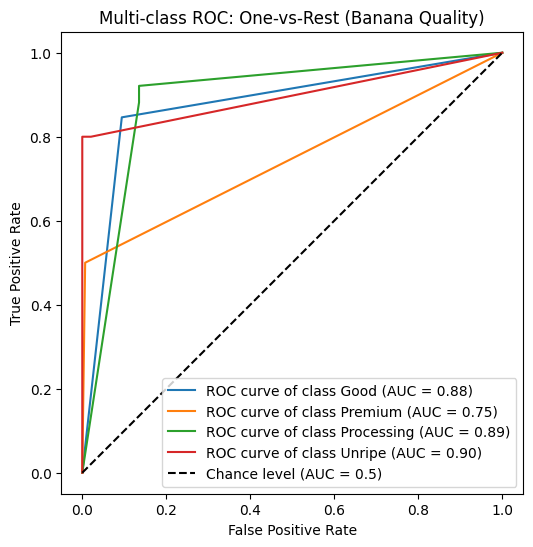

AUC Scores for each class:
Class Good: AUC = 0.88
Class Premium: AUC = 0.75
Class Processing: AUC = 0.89
Class Unripe: AUC = 0.90


In [ ]:
# Plot the ROC curves for each class

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y2_test_binary[:, i],
        y2_prob_test[:, i],
        name=f"ROC curve of class {le_target.classes_[i]}",
        ax=ax,
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC: One-vs-Rest (Banana Quality)")
plt.legend()
plt.show()

# AUC Scores for each class

print("AUC Scores for each class:")
for i in range(n_classes):
    auc_score = roc_auc_score(y2_test_binary[:, i], y2_prob_test[:, i])
    print(f"Class {le_target.classes_[i]}: AUC = {auc_score:.2f}")

The individual AUC scores show a similar trend to what has been observed in the other evaluation metrics. All the classes expect "Premium" tend to be categorized well by the model. The "Premium" class has the lowest AUC score, which is consistent with the lower precision and recall observed in the classification report which suggests the model has more difficulty distinguishing "Premium" bananas from the other classes, likely due to the class imbalance and the small differences in features that characterize "Premium" quality bananas.